<a href="https://colab.research.google.com/github/hankymun/ex_2.11-2.14/blob/main/2_11_2_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#2.13
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import itertools

product_demand = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'product_demand')
store_reputation = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'store_reputation')
profit_margin = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'profit_margin')
competitor_pricing_pressure = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'competitor_pricing_pressure')
seasonal_demand = ctrl.Antecedent(np.arange(0, 30.1, 0.1), 'seasonal_demand')

discount_percentage = ctrl.Consequent(np.arange(0, 70.1, 0.1), 'discount_percentage')

def create_fuzzy_sets(variable, low_params, mid_params, high_params):
    variable['low'] = fuzz.trimf(variable.universe, low_params)
    variable['mid'] = fuzz.trimf(variable.universe, mid_params)
    variable['high'] = fuzz.trimf(variable.universe, high_params)

create_fuzzy_sets(product_demand, [0, 5, 7], [6, 7, 8], [7, 9, 10])
create_fuzzy_sets(store_reputation, [0, 4, 4], [4, 4.3, 4.5], [4.5, 5, 5])
create_fuzzy_sets(profit_margin, [0, 5, 7], [6, 7, 8], [7, 9, 10])
create_fuzzy_sets(competitor_pricing_pressure, [0, 5, 7], [6, 7, 8], [7, 9, 10])
create_fuzzy_sets(seasonal_demand, [0, 13, 15], [15, 15, 15], [15, 17, 30])

discount_percentage['very_low'] = fuzz.trimf(discount_percentage.universe, [0, 0, 5])
discount_percentage['low'] = fuzz.trimf(discount_percentage.universe, [0, 5, 10])
discount_percentage['mid'] = fuzz.trimf(discount_percentage.universe, [5, 15, 25])
discount_percentage['high'] = fuzz.trimf(discount_percentage.universe, [15, 30, 45])
discount_percentage['very_high'] = fuzz.trimf(discount_percentage.universe, [30, 70, 70])

rules = []
terms = ['low', 'mid', 'high']

def get_discount_score(var_name, term):
    if var_name in ['profit_margin', 'competitor_pricing_pressure']:
        return {'low': 1, 'mid': 2, 'high': 3}[term]
    else:
        return {'low': 3, 'mid': 2, 'high': 1}[term]

for d, r, m, p, s in itertools.product(terms, repeat=5):
    score = sum([
        get_discount_score('product_demand', d),
        get_discount_score('store_reputation', r),
        get_discount_score('profit_margin', m),
        get_discount_score('competitor_pricing_pressure', p),
        get_discount_score('seasonal_demand', s)
    ])

    if score <= 7:
        out_term = 'very_low'
    elif score <= 9:
        out_term = 'low'
    elif score <= 11:
        out_term = 'mid'
    elif score <= 13:
        out_term = 'high'
    else:
        out_term = 'very_high'

    rule = ctrl.Rule(
        product_demand[d] &
        store_reputation[r] &
        profit_margin[m] &
        competitor_pricing_pressure[p] &
        seasonal_demand[s],
        discount_percentage[out_term]
    )
    rules.append(rule)

discount_ctrl = ctrl.ControlSystem(rules)
discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)

product_demand.view()
store_reputation.view()
profit_margin.view()
competitor_pricing_pressure.view()
seasonal_demand.view()
discount_percentage.view()

#vidu
discount_sim.input['product_demand'] = 3.0
discount_sim.input['store_reputation'] = 3.5
discount_sim.input['profit_margin'] = 9.0
discount_sim.input['competitor_pricing_pressure'] = 8.5
discount_sim.input['seasonal_demand'] = 15

discount_sim.compute()

print(f"Mức % Giảm giá đề xuất: {discount_sim.output['discount_percentage']:.2f}%")

ModuleNotFoundError: No module named 'skfuzzy'

-> Mức giá áp dụng (0-100): 91.73
-> Điểm thưởng cộng thêm (0-100): 50.00


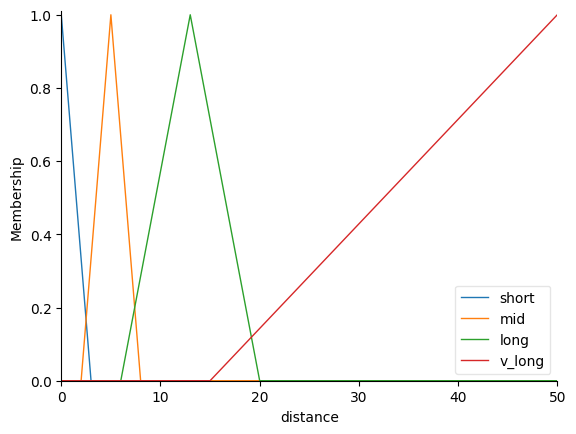

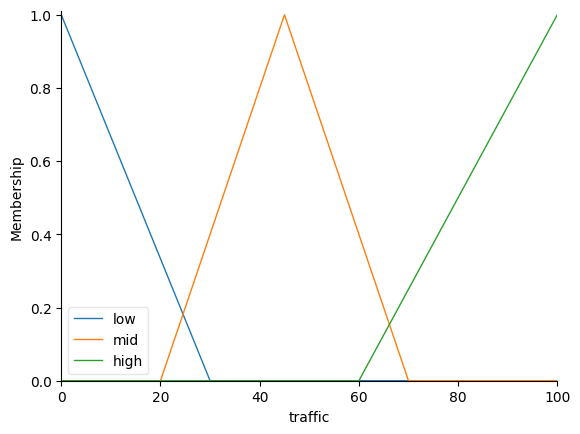

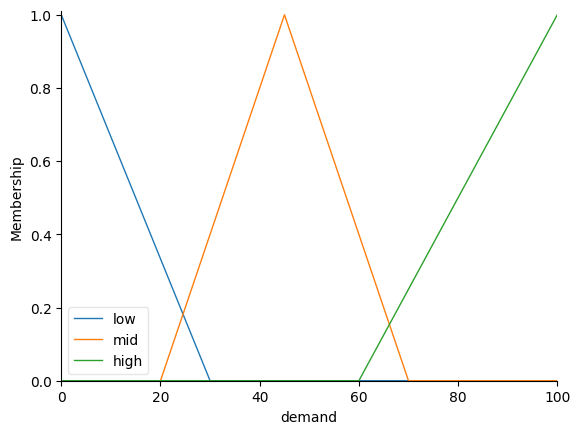

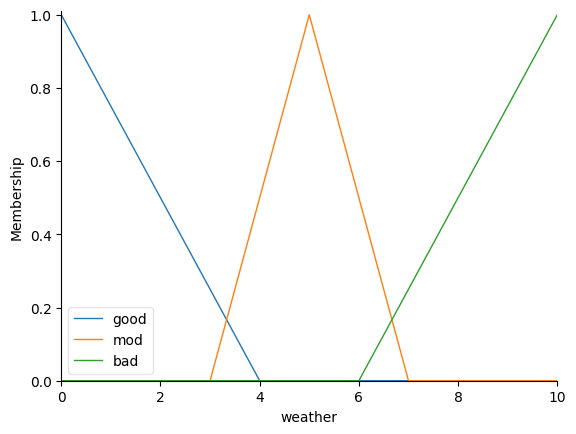

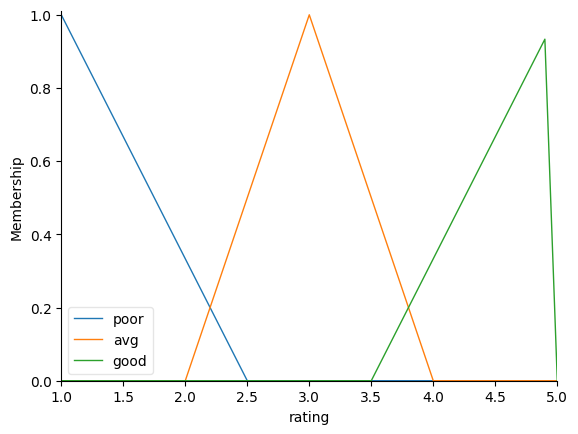

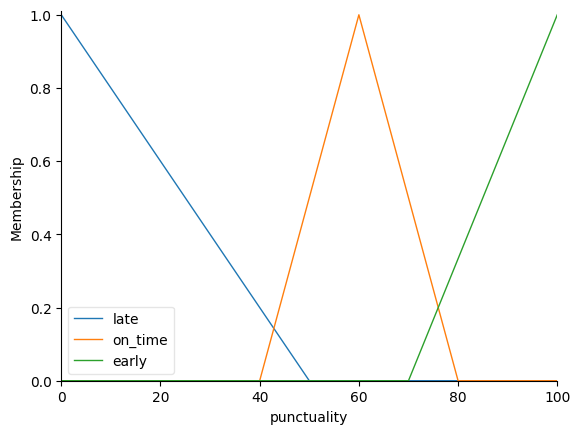

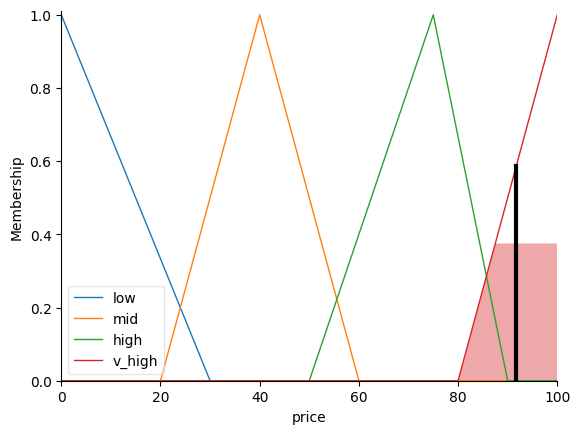

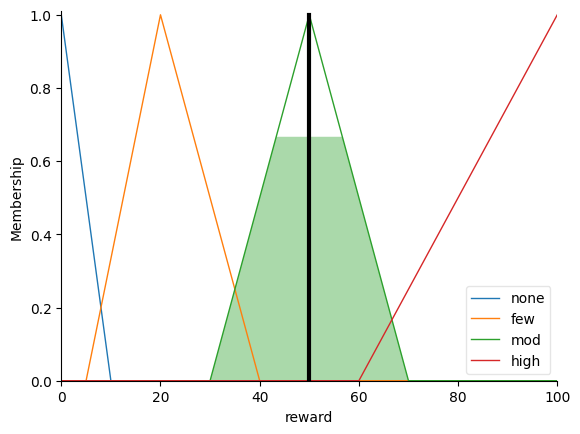

In [ ]:
#2.11
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import itertools
import matplotlib.pyplot as plt

distance = ctrl.Antecedent(np.arange(0, 50.1, 0.1), 'distance')
traffic = ctrl.Antecedent(np.arange(0, 100.1, 1), 'traffic')
demand = ctrl.Antecedent(np.arange(0, 100.1, 1), 'demand')
weather = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'weather')

rating = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'rating')
punctuality = ctrl.Antecedent(np.arange(0, 100.1, 1), 'punctuality')

price = ctrl.Consequent(np.arange(0, 100.1, 1), 'price')
reward = ctrl.Consequent(np.arange(0, 100.1, 1), 'reward')

distance['short'] = fuzz.trimf(distance.universe, [0, 0, 3])
distance['mid'] = fuzz.trimf(distance.universe, [2, 5, 8])
distance['long'] = fuzz.trimf(distance.universe, [6, 13, 20])
distance['v_long'] = fuzz.trimf(distance.universe, [15, 50, 50])

traffic['low'] = fuzz.trimf(traffic.universe, [0, 0, 30])
traffic['mid'] = fuzz.trimf(traffic.universe, [20, 45, 70])
traffic['high'] = fuzz.trimf(traffic.universe, [60, 100, 100])

demand['low'] = fuzz.trimf(demand.universe, [0, 0, 30])
demand['mid'] = fuzz.trimf(demand.universe, [20, 45, 70])
demand['high'] = fuzz.trimf(demand.universe, [60, 100, 100])

weather['good'] = fuzz.trimf(weather.universe, [0, 0, 4])
weather['mod'] = fuzz.trimf(weather.universe, [3, 5, 7])
weather['bad'] = fuzz.trimf(weather.universe, [6, 10, 10])

rating['poor'] = fuzz.trimf(rating.universe, [1, 1, 2.5])
rating['avg'] = fuzz.trimf(rating.universe, [2, 3, 4])
rating['good'] = fuzz.trimf(rating.universe, [3.5, 5, 5])

punctuality['late'] = fuzz.trimf(punctuality.universe, [0, 0, 50])
punctuality['on_time'] = fuzz.trimf(punctuality.universe, [40, 60, 80])
punctuality['early'] = fuzz.trimf(punctuality.universe, [70, 100, 100])

price['low'] = fuzz.trimf(price.universe, [0, 0, 30])
price['mid'] = fuzz.trimf(price.universe, [20, 40, 60])
price['high'] = fuzz.trimf(price.universe, [50, 75, 90])
price['v_high'] = fuzz.trimf(price.universe, [80, 100, 100])

reward['none'] = fuzz.trimf(reward.universe, [0, 0, 10])
reward['few'] = fuzz.trimf(reward.universe, [5, 20, 40])
reward['mod'] = fuzz.trimf(reward.universe, [30, 50, 70])
reward['high'] = fuzz.trimf(reward.universe, [60, 100, 100])

rules = []

def get_price_score(d, t, dem, w):
    score = {'short': 1, 'mid': 2, 'long': 3, 'v_long': 4}[d]
    score += {'low': 0, 'mid': 1, 'high': 2}[t]
    score += {'low': 0, 'mid': 1, 'high': 2}[dem]
    score += {'good': 0, 'mod': 1, 'bad': 2}[w]
    return score

for d, t, dem, w in itertools.product(['short', 'mid', 'long', 'v_long'], ['low', 'mid', 'high'], ['low', 'mid', 'high'], ['good', 'mod', 'bad']):
    score = get_price_score(d, t, dem, w)

    if score <= 3: out_price = 'low'
    elif score <= 5: out_price = 'mid'
    elif score <= 7: out_price = 'high'
    else: out_price = 'v_high'

    rules.append(ctrl.Rule(distance[d] & traffic[t] & demand[dem] & weather[w], price[out_price]))

def get_reward_score(r, p):
    return {'poor': 0, 'avg': 1, 'good': 2}[r] + {'late': 0, 'on_time': 1, 'early': 2}[p]

for r, p in itertools.product(['poor', 'avg', 'good'], ['late', 'on_time', 'early']):
    score = get_reward_score(r, p)

    if score == 0: out_reward = 'none'
    elif score == 1: out_reward = 'few'
    elif score <= 3: out_reward = 'mod'
    else: out_reward = 'high'

    rules.append(ctrl.Rule(rating[r] & punctuality[p], reward[out_reward]))

system_ctrl = ctrl.ControlSystem(rules)
system_sim = ctrl.ControlSystemSimulation(system_ctrl)
#vidu
system_sim.input['distance'] = 12.0
system_sim.input['traffic'] = 85.0
system_sim.input['demand'] = 75.0
system_sim.input['weather'] = 8.0
system_sim.input['rating'] = 4.5
system_sim.input['punctuality'] = 65.0

system_sim.compute()


print(f"-> Mức giá áp dụng (0-100): {system_sim.output['price']:.2f}")
print(f"-> Điểm thưởng cộng thêm (0-100): {system_sim.output['reward']:.2f}")

distance.view()
traffic.view()
demand.view()
weather.view()
rating.view()
punctuality.view()
price.view(sim=system_sim)
reward.view(sim=system_sim)
plt.show()

Tổng số luật: 243
Tỉ lệ chiết khấu đề xuất: 40.94%


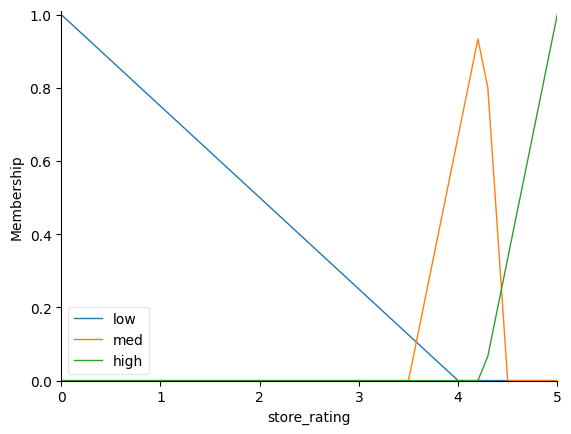

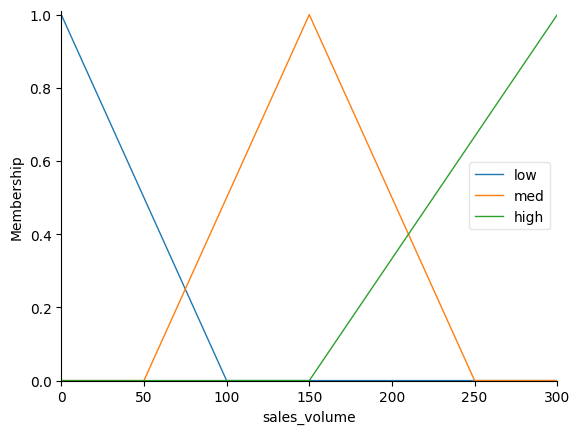

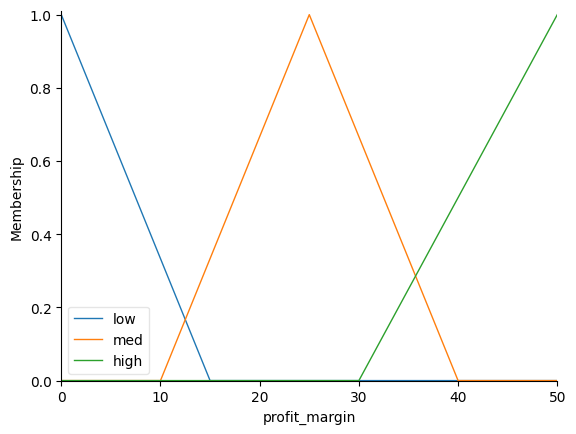

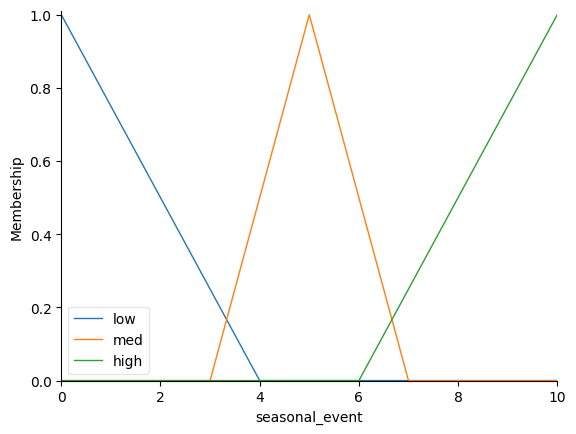

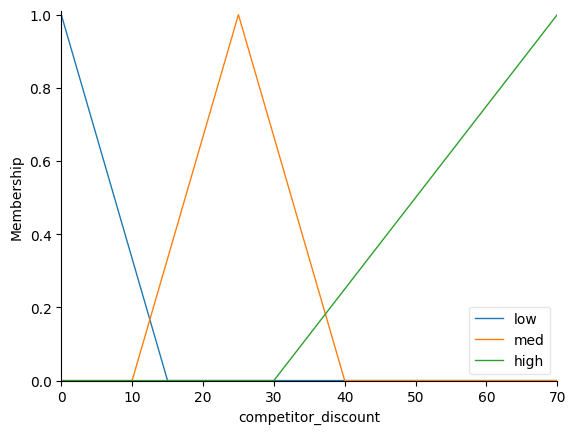

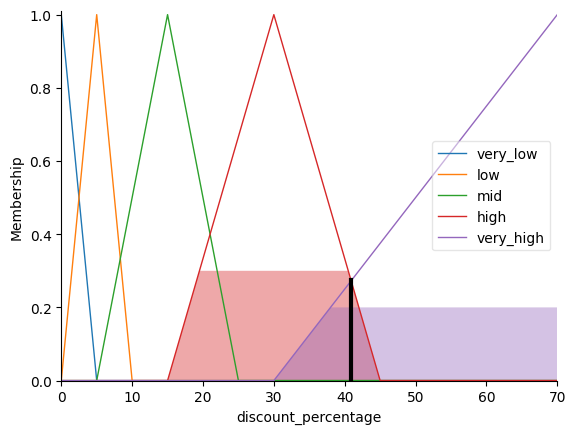

In [ ]:
#2.12
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import itertools
import matplotlib.pyplot as plt

store_rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'store_rating')
sales_volume = ctrl.Antecedent(np.arange(0, 301, 1), 'sales_volume')
profit_margin = ctrl.Antecedent(np.arange(0, 51, 1), 'profit_margin')
seasonal_event = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'seasonal_event')
competitor_discount = ctrl.Antecedent(np.arange(0, 71, 1), 'competitor_discount')

discount_percentage = ctrl.Consequent(np.arange(0, 70.1, 0.1), 'discount_percentage')

store_rating['low'] = fuzz.trimf(store_rating.universe, [0, 0, 4])
store_rating['med'] = fuzz.trimf(store_rating.universe, [3.5, 4.25, 4.5])
store_rating['high'] = fuzz.trimf(store_rating.universe, [4.25, 5, 5])

sales_volume['low'] = fuzz.trimf(sales_volume.universe, [0, 0, 100])
sales_volume['med'] = fuzz.trimf(sales_volume.universe, [50, 150, 250])
sales_volume['high'] = fuzz.trimf(sales_volume.universe, [150, 300, 300])

profit_margin['low'] = fuzz.trimf(profit_margin.universe, [0, 0, 15])
profit_margin['med'] = fuzz.trimf(profit_margin.universe, [10, 25, 40])
profit_margin['high'] = fuzz.trimf(profit_margin.universe, [30, 50, 50])

seasonal_event['low'] = fuzz.trimf(seasonal_event.universe, [0, 0, 4])
seasonal_event['med'] = fuzz.trimf(seasonal_event.universe, [3, 5, 7])
seasonal_event['high'] = fuzz.trimf(seasonal_event.universe, [6, 10, 10])

competitor_discount['low'] = fuzz.trimf(competitor_discount.universe, [0, 0, 15])
competitor_discount['med'] = fuzz.trimf(competitor_discount.universe, [10, 25, 40])
competitor_discount['high'] = fuzz.trimf(competitor_discount.universe, [30, 70, 70])

discount_percentage['very_low'] = fuzz.trimf(discount_percentage.universe, [0, 0, 5])
discount_percentage['low'] = fuzz.trimf(discount_percentage.universe, [0, 5, 10])
discount_percentage['mid'] = fuzz.trimf(discount_percentage.universe, [5, 15, 25])
discount_percentage['high'] = fuzz.trimf(discount_percentage.universe, [15, 30, 45])
discount_percentage['very_high'] = fuzz.trimf(discount_percentage.universe, [30, 70, 70])

rules = []

def get_discount_score(var_name, term):
    if var_name in ['store_rating', 'sales_volume']:
        return {'low': 3, 'med': 2, 'high': 1}[term]
    else:
        return {'low': 1, 'med': 2, 'high': 3}[term]

for sr, sv, pm, se, cd in itertools.product(['low', 'med', 'high'], repeat=5):
    score = sum([
        get_discount_score('store_rating', sr),
        get_discount_score('sales_volume', sv),
        get_discount_score('profit_margin', pm),
        get_discount_score('seasonal_event', se),
        get_discount_score('competitor_discount', cd)
    ])

    if score <= 7: out_term = 'very_low'
    elif score <= 9: out_term = 'low'
    elif score <= 11: out_term = 'mid'
    elif score <= 13: out_term = 'high'
    else: out_term = 'very_high'

    rules.append(ctrl.Rule(
        store_rating[sr] &
        sales_volume[sv] &
        profit_margin[pm] &
        seasonal_event[se] &
        competitor_discount[cd],
        discount_percentage[out_term]
    ))

system_ctrl = ctrl.ControlSystem(rules)
system_sim = ctrl.ControlSystemSimulation(system_ctrl)

system_sim.input['store_rating'] = 3.8
system_sim.input['sales_volume'] = 80
system_sim.input['profit_margin'] = 35
system_sim.input['seasonal_event'] = 8.0
system_sim.input['competitor_discount'] = 45

system_sim.compute()

print(f"Tổng số luật: {len(rules)}")
print(f"Tỉ lệ chiết khấu đề xuất: {system_sim.output['discount_percentage']:.2f}%")

store_rating.view()
sales_volume.view()
profit_margin.view()
seasonal_event.view()
competitor_discount.view()
discount_percentage.view(sim=system_sim)
plt.show()

Số lượng đơn hàng đề xuất kết hợp: 8 đơn
Mức độ ưu tiên giao hàng (0-100): 68.94


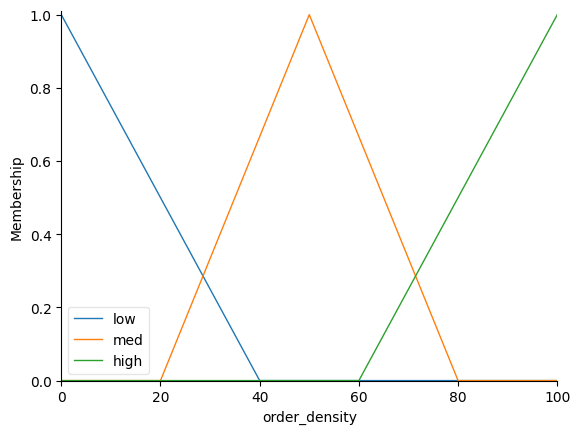

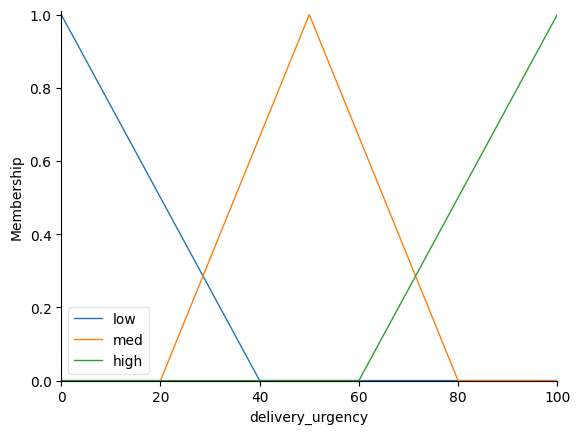

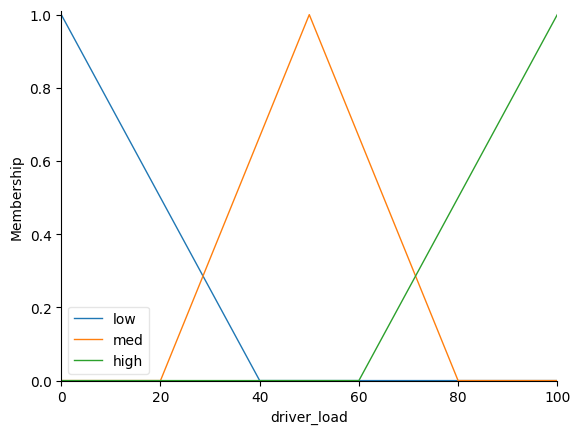

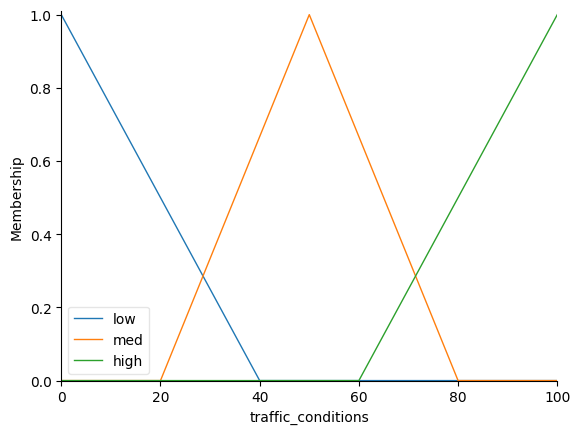

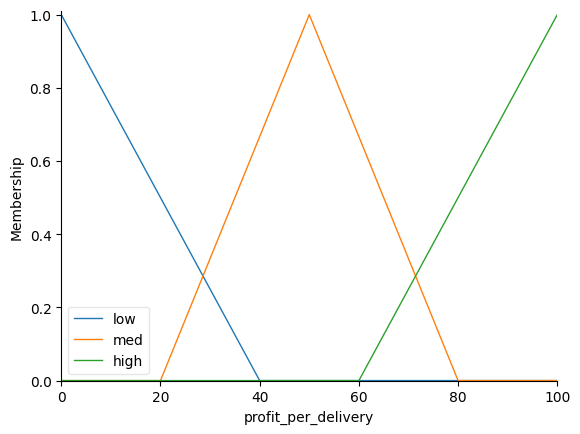

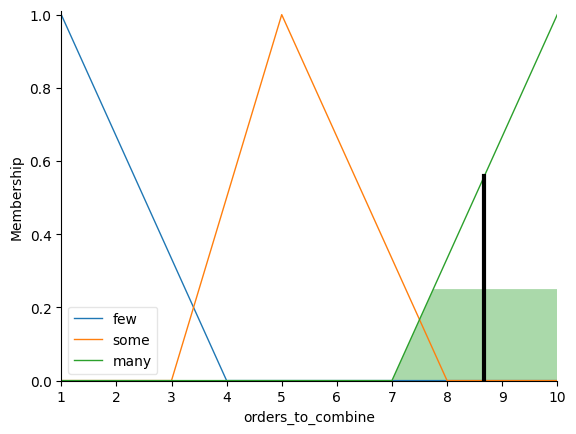

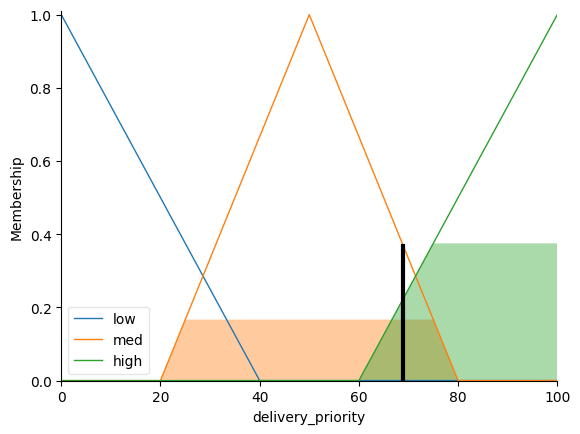

In [ ]:
#2.14
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import math

order_density = ctrl.Antecedent(np.arange(0, 101, 1), 'order_density')
delivery_urgency = ctrl.Antecedent(np.arange(0, 101, 1), 'delivery_urgency')
driver_load = ctrl.Antecedent(np.arange(0, 101, 1), 'driver_load')
traffic_conditions = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic_conditions')
profit_per_delivery = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_per_delivery')

orders_to_combine = ctrl.Consequent(np.arange(1, 11, 1), 'orders_to_combine')
delivery_priority = ctrl.Consequent(np.arange(0, 101, 1), 'delivery_priority')

order_density['low'] = fuzz.trimf(order_density.universe, [0, 0, 40])
order_density['med'] = fuzz.trimf(order_density.universe, [20, 50, 80])
order_density['high'] = fuzz.trimf(order_density.universe, [60, 100, 100])

delivery_urgency['low'] = fuzz.trimf(delivery_urgency.universe, [0, 0, 40])
delivery_urgency['med'] = fuzz.trimf(delivery_urgency.universe, [20, 50, 80])
delivery_urgency['high'] = fuzz.trimf(delivery_urgency.universe, [60, 100, 100])

driver_load['low'] = fuzz.trimf(driver_load.universe, [0, 0, 40])
driver_load['med'] = fuzz.trimf(driver_load.universe, [20, 50, 80])
driver_load['high'] = fuzz.trimf(driver_load.universe, [60, 100, 100])

traffic_conditions['low'] = fuzz.trimf(traffic_conditions.universe, [0, 0, 40])
traffic_conditions['med'] = fuzz.trimf(traffic_conditions.universe, [20, 50, 80])
traffic_conditions['high'] = fuzz.trimf(traffic_conditions.universe, [60, 100, 100])

profit_per_delivery['low'] = fuzz.trimf(profit_per_delivery.universe, [0, 0, 40])
profit_per_delivery['med'] = fuzz.trimf(profit_per_delivery.universe, [20, 50, 80])
profit_per_delivery['high'] = fuzz.trimf(profit_per_delivery.universe, [60, 100, 100])

orders_to_combine['few'] = fuzz.trimf(orders_to_combine.universe, [1, 1, 4])
orders_to_combine['some'] = fuzz.trimf(orders_to_combine.universe, [3, 5, 8])
orders_to_combine['many'] = fuzz.trimf(orders_to_combine.universe, [7, 10, 10])

delivery_priority['low'] = fuzz.trimf(delivery_priority.universe, [0, 0, 40])
delivery_priority['med'] = fuzz.trimf(delivery_priority.universe, [20, 50, 80])
delivery_priority['high'] = fuzz.trimf(delivery_priority.universe, [60, 100, 100])

rule1 = ctrl.Rule(order_density['high'] & driver_load['low'] & traffic_conditions['low'], orders_to_combine['many'])
rule2 = ctrl.Rule(order_density['med'] & traffic_conditions['high'] & delivery_urgency['med'], orders_to_combine['few'])
rule3 = ctrl.Rule(driver_load['high'] & order_density['high'] & profit_per_delivery['med'], orders_to_combine['some'])
rule4 = ctrl.Rule(order_density['low'] & delivery_urgency['high'] & traffic_conditions['med'], orders_to_combine['few'])
rule5 = ctrl.Rule(profit_per_delivery['high'] & delivery_urgency['high'] & traffic_conditions['high'], orders_to_combine['few'])

rule6 = ctrl.Rule(delivery_urgency['high'] & profit_per_delivery['high'], delivery_priority['high'])
rule7 = ctrl.Rule(delivery_urgency['med'] & traffic_conditions['med'], delivery_priority['med'])
rule8 = ctrl.Rule(delivery_urgency['low'] & order_density['high'] & profit_per_delivery['low'], delivery_priority['low'])

system_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8])
system_sim = ctrl.ControlSystemSimulation(system_ctrl)

system_sim.input['order_density'] = 85
system_sim.input['delivery_urgency'] = 75
system_sim.input['driver_load'] = 20
system_sim.input['traffic_conditions'] = 30
system_sim.input['profit_per_delivery'] = 80

system_sim.compute()

orders_combined = math.floor(system_sim.output['orders_to_combine'])

print(f"Số lượng đơn hàng đề xuất kết hợp: {orders_combined} đơn")
print(f"Mức độ ưu tiên giao hàng (0-100): {system_sim.output['delivery_priority']:.2f}")

order_density.view()
delivery_urgency.view()
driver_load.view()
traffic_conditions.view()
profit_per_delivery.view()
orders_to_combine.view(sim=system_sim)
delivery_priority.view(sim=system_sim)
plt.show()

In [ ]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 11.5 MB/s eta 0:00:00
